<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/LB1%2C2%2C3%2C6_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Філімонова Тетяна. Варіант 3

Старшун Софія, ФІТ 2-17, ЛБ№6

Значення у точці x = -4.0: -18.0000
Значення у точці x = -2.0: 8.0000
Значення у точці x = -1.5: 6.3750
Значення у точці x = 0.5: -10.1250


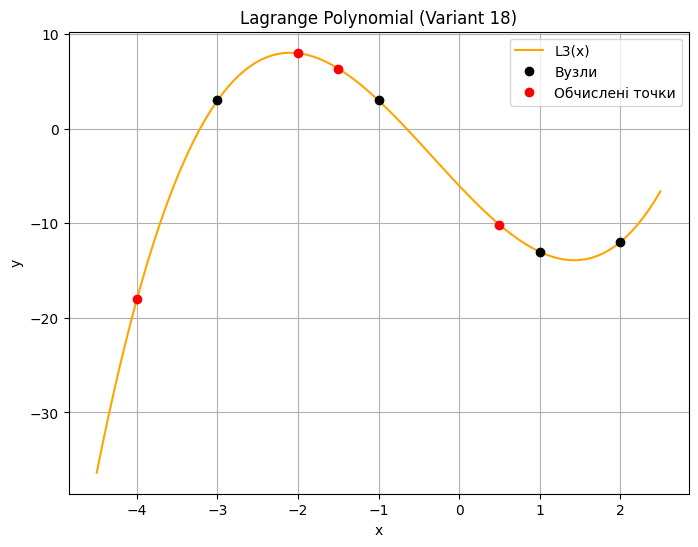

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

x = np.array([-3., -1., 1., 2.], dtype=float)
y = np.array([3., 3., -13., -12.], dtype=float)
test_points = np.array([-4., -2., -1.5, 0.5])

def lagrange_interpolation(x, y, x_test):
    n = len(x)
    p = np.zeros(n)
    for i in range(n):
        p_i = 1
        for j in range(n):
            if i != j:
                p_i *= (x_test - x[j]) / (x[i] - x[j])
        p[i] = p_i
    return np.dot(y, p)

results = [lagrange_interpolation(x, y, tp) for tp in test_points]

for tp, res in zip(test_points, results):
    print(f"Значення у точці x = {tp}: {res:.4f}")

x_new = np.linspace(-4.5, 2.5, 100)
y_new = [lagrange_interpolation(x, y, i) for i in x_new]

plt.figure(figsize=(8, 6))
plt.plot(x_new, y_new, label='L3(x)', color='orange')
plt.plot(x, y, 'ko', label='Вузли')
plt.plot(test_points, results, 'ro', label='Обчислені точки')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Polynomial (Variant 18)')
plt.grid(True)
plt.legend()
plt.show()

Старшун Софія, ФІТ 2-17, ЛБ№3

In [ ]:
import numpy as np
import numdifftools as nd

f = lambda x: 2*x**4 - 8*x**3 - 16*x**2 - 1

def find_segments(): # відокремлюємо корені
    search_range = np.arange(-10, 10, 1)
    a = None
    previous_x = None
    current_x = None
    segments = []
    for x in search_range:
        x = round(x, 4)
        current_x = f(x)
        if previous_x is not None and previous_x * current_x < 0:
            segments.append((a, x))
        a = x
        previous_x = current_x
    return segments

segments = find_segments()
for a, b in segments:
    print(f'Found segment: [{a}, {b}]')

#. Лабораторна робота 3 . М. Ньютона, комбінований метод

def nuton(a, b, eps, f):
    df2 = nd.Derivative(f, n=2)(b)
    if f(b) * df2 > 0:
        xi = b
    else:
        xi = a

    df = nd.Derivative(f, n=1)(xi)
    xi_1 = xi - f(xi) / df
    while abs(xi_1 - xi) > eps:
        xi = xi_1

        df = nd.Derivative(f, n=1)(xi)
        xi_1 = xi - f(xi) / df
    print('Метод Ньютона, x = ', xi_1.round(4))

def komb(a, b, eps, f):

    if nd.Derivative(f, n=1)(a) * nd.Derivative(f, n=2)(a) > 0:
        a0 = a
        b0 = b
    else:
        a0 = b
        b0 = a

    ai = a0
    bi = b0
    while abs(ai - bi) > eps:
        ai_1 = ai - f(ai) * (bi - ai) / (f(bi) - f(ai))
        bi_1 = bi - f(bi) / nd.Derivative(f, n=1)(bi)
        ai = ai_1
        bi = bi_1

    x = (ai_1 + bi_1) / 2
    print('Комбінований метод, x = ', x.round(4))

if __name__ == "__main__":

    a1, b1 = -2, -1
    a2, b2 = 5, 6
    eps = 0.0001

    print(f"\nРозв'язки на відрізку [{a1}, {b1}]")
    nuton(a1, b1, eps, f)
    komb(a1, b1, eps, f)

    print(f"\nРозв'язки на відрізку [{a2}, {b2}]")
    nuton(a2, b2, eps, f)
    komb(a2, b2, eps, f)

Found segment: [-2, -1]
Found segment: [5, 6]

Розв'язки на відрізку [-2, -1]
Метод Ньютона, x =  -1.4962
Комбінований метод, x =  -1.4962

Розв'язки на відрізку [5, 6]
Метод Ньютона, x =  5.4665
Комбінований метод, x =  5.4665


Старшун Софія, ФІТ 2-17, ЛБ№2

In [ ]:
import math
import numpy as np
import numdifftools as nd

def f(x):
    return 2*pow(x, 4) - 8*pow(x, 3) - 16*pow(x, 2) - 1
eps = 0.0001

def find_segments():
    search_range = np.arange(-10, 10, 1)
    a_start = None
    previous_f = None
    segments = []

    for x in search_range:
        x = round(x, 4)
        current_f = f(x)
        if previous_f is not None and previous_f * current_f < 0:
            segments.append((a_start, x))
        a_start = x
        previous_f = current_f
    return segments

def rec(a, b, eps):
    while (abs(a - b) > eps):
        if f(a) * f((a + b) / 2) < 0:
            b = (a + b) / 2
        else:
            a = (a + b) / 2
    x = (a + b) / 2
    print('x =', round(x, 5), ' - Half division method')

def hord(a, b, eps):
    d2f = nd.Derivative(f, n=2)

    if f(a) * d2f(a) > 0:
        x0 = a
        xi = b
    else:
        x0 = b
        xi = a

    xi_1 = xi - (xi - x0) * f(xi) / (f(xi) - f(x0))
    while (abs(xi_1 - xi) > eps):
        xi = xi_1
        xi_1 = xi - (xi - x0) * f(xi) / (f(xi) - f(x0))
    print('x =', round(xi_1, 5), ' - Chord method')

found_segments = find_segments()
for a_seg, b_seg in found_segments:
    print(f'Found segment: [{a_seg}, {b_seg}]')

a1, b1 = -2.0, -1.0
a2, b2 = 5.0, 6.0

print(f'\nSolution of a nonlinear equation on a segment [{a1}, {b1}]')
rec(a1, b1, eps)
hord(a1, b1, eps)

print(f'\nSolution of a nonlinear equation on a segment [{a2}, {b2}]')
rec(a2, b2, eps)
hord(a2, b2, eps)

Found segment: [-2, -1]
Found segment: [5, 6]

Solution of a nonlinear equation on a segment [-2.0, -1.0]
x = -1.49619  - Half division method
x = -1.49614  - Chord method

Solution of a nonlinear equation on a segment [5.0, 6.0]
x = 5.46652  - Half division method
x = 5.4665  - Chord method


In [ ]:
!pip install numdifftools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.7 MB/s eta 0:00:00


Старшун Софія, ФІТ 2-17, ЛБ№1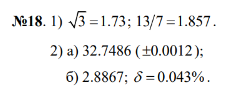

In [ ]:
import numpy as np

def f(x, y):
    return np.abs(x - y) / np.abs(x)

def main():
    x1 = np.sqrt(3) # Точне значення sqrt(3)
    x2 = 13 / 7 # Точне значення 13/7
    x1_1 = 1.73 # Наближене значення sqrt(3)
    x2_2 = 1.857 # Наближене значення 13/7

    rel_error_x1 = f(x1, x1_1)
    rel_error_x2 = f(x2, x2_2)

    if rel_error_x1 < rel_error_x2:
        print("Перша рівність точніше з відносною похибкою:", round(rel_error_x1, 5))
    elif rel_error_x2 < rel_error_x1:
        print("Друга рівність точніше з відносною похибкою:", round(rel_error_x2, 5))
    else:
        print("Обидві рівності мають однакову точність з відносною похибкою:", round(rel_error_x2, 5))

if __name__ == "__main__":
  main()

Друга рівність точніше з відносною похибкою: 8e-05


In [ ]:
import numpy as np
import pandas as pd

# Визначаємо функцію
def f (x):
    y = np.cos(x)*np.sin(x)*(x**2+x+1)
    return y
# Визначаємо границі відрізку
a, b = -3, -1
# Визначаємо точність розв'язку
eps = 0.001
# Поділяємо відрізок навпіл
c = (a+b)/2
# Зберігаємо результати обчислень
data_A = [a]
data_B = [b]
data_C = [c]
data_F_A = [f(a)]
data_F_B = [f(b)]
data_F_C = [f(c)]
# Перевіряємо досягнення точності
while np.abs(f(c)) > eps:
    # Звужуємо відрізок
    if np.sign(f(c)) == np.sign(f(a)):
        a = c
    else:
        b = c
    # Поділяємо відрізок навпіл
    c = (a+b)/2
    # Зберігаємо результати обчислень
    data_A.append(a)
    data_B.append(b)
    data_C.append(c)
    data_F_A.append(f(a))
    data_F_B.append(f(b))
    data_F_C.append(f(c))
# Відображаємо результати обчислень
print('Результати обчислень')
print()
data = pd.DataFrame({'a': data_A,
                     'F(a)': data_F_A,
                     'c': data_C,
                     'F(c)': data_F_C,
                     'b': data_B,
                     'F(b)': data_F_B})
print(data)
# Відображаємо наближений корінь рівняння
print()
print('В точці с = ', c, ', f(c) = ', f(c))

Результати обчислень

          a      F(a)         c      F(c)       b      F(b)
0 -3.000000  0.977954 -2.000000  1.135204 -1.0000 -0.454649
1 -2.000000  1.135204 -1.500000 -0.123480 -1.0000 -0.454649
2 -2.000000  1.135204 -1.750000  0.405593 -1.5000 -0.123480
3 -1.750000  0.405593 -1.625000  0.109040 -1.5000 -0.123480
4 -1.625000  0.109040 -1.562500 -0.015587 -1.5000 -0.123480
5 -1.625000  0.109040 -1.593750  0.044659 -1.5625 -0.015587
6 -1.593750  0.044659 -1.578125  0.014015 -1.5625 -0.015587
7 -1.578125  0.014015 -1.570312 -0.000917 -1.5625 -0.015587

В точці с =  -1.5703125 , f(c) =  -0.0009171268569415665


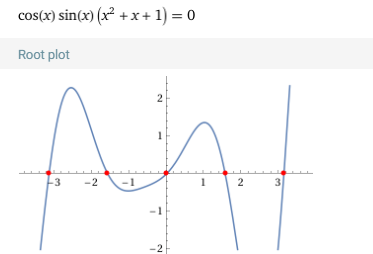

2. Метод ділення навпіл

In [ ]:
import numpy as np
import scipy.optimize as sp

def f(x):
    y = np.cos(x)*np.sin(x)*(x**2+x+1)
    return y

a, b = -3, -1
eps = 1.e-3

x = sp.bisect(f, a, b,(),eps) #функція для метода

print('The approximate solution x is:', x)
print('And the value f(x) is:', f(x))

The approximate solution x is: -1.5712890625
And the value f(x) is: 0.0009350448126615916


3. Метод хорд

In [ ]:
import numpy as np
import pandas as pd
# Визначаємо функцію
def f(x):
    y = np.cos(x)*np.sin(x)*(x**2+x+1)
    return y
# Визначаємо межі відрізку
a, b = -3, -1
# Визначаємо точність розв'язку
eps = 0.001
# Точка, де хорда перетинає вісь 0x
c = (f(a)*b-a*f(b))/(f(a)-f(b))

# Зберігаємо результати обчислень
data_A = [a]
data_B = [b]
data_C = [c]
data_F_A = [f(a)]
data_F_B = [f(b)]
data_F_C = [f(c)]
# Перевіряємо досягнення точності
while np.abs(f(c)) > eps:
    # Звужуємо відрізок
    if np.sign(f(c)) == np.sign(f(a)):
        a = c
    else:
        b = c
    # Точка, де хорда перетинає вісь 0x
    c = (f(a)*b-a*f(b))/(f(a)-f(b))
    # Зберігаємо результати обчислень
    data_A.append(a)
    data_B.append(b)
    data_C.append(c)
    data_F_A.append(f(a))
    data_F_B.append(f(b))
    data_F_C.append(f(c))
# Відображаємо результати обчислень
print('Результати обчислень')
print()
data = pd.DataFrame({'a': data_A, 'F(a)': data_F_A,
                     'c': data_C, 'F(c)': data_F_C,
                     'b': data_B, 'F(b)': data_F_B})
print(data)
# Відображаємо наближений корінь рівняння
print()
print('В точці с = ', c, ', f(c) = ', f(c))

Результати обчислень

          a      F(a)         c      F(c)         b      F(b)
0 -3.000000  0.977954 -1.634717  0.129889 -1.000000 -0.454649
1 -1.634717  0.129889 -1.493678 -0.133455 -1.000000 -0.454649
2 -1.634717  0.129889 -1.565152 -0.010636 -1.493678 -0.133455
3 -1.634717  0.129889 -1.570418 -0.000718 -1.565152 -0.010636

В точці с =  -1.5704175737258015 , f(c) =  -0.0007180376446871882


4. Метод Ньютона (дотичних)

In [ ]:
import numpy as np
import pandas as pd
# Визначаємо функцію
def f(x):
    y = np.cos(x)*np.sin(x)*(x**2+x+1)
    return y

# Визначаємо межі відрізку
a, b = -3, -1

# Визначаємо першу похідну
def df(x):
    y1 = -(x**2+x+1)*(np.sin(x))**2
    y2 = (x**2+x+1)*(np.cos(x))**2
    y3 = (2*x+1)*np.sin(x)*np.cos(x)
    y = y1+y2+y3
    return y
# Визначаємо початкову точку
c = -1.4
# Визначаємо точність розв'язку
eps = 0.001

# Зберігаємо результати обчислень
data_C = [c]
data_F_C = [f(c)]

# Перевіряємо досягнення точності
while np.abs(f(c)) > eps:
    # Точка, де дотична перетинає вісь 0x
    c -= f(c)/df(c)
    # Зберігаємо результати обчислень
    data_C.append(c)
    data_F_C.append(f(c))
# Відображаємо результати обчислень
print('Результати обчислень')
print()
data = pd.DataFrame({'c': data_C, 'F(c)': data_F_C})
print(data)
# Відображаємо наближений корінь рівняння
print()
print('В точці с = ', c, ', f(c) = ', f(c))

Результати обчислень

          c      F(c)
0 -1.400000 -0.261291
1 -1.623636  0.106144
2 -1.573564  0.005266
3 -1.570805  0.000016

В точці с =  -1.5708049170979717 , f(c) =  1.6292567852764437e-05


5. Метод Ньютона (дотичних)

In [ ]:
import numpy as np
import scipy.optimize as sp

def f(x):
    y = np.cos(x)*np.sin(x)*(x**2+x+1)
    return y

def df(x):# Обчислення похідної
    y1 = -(x**2+x+1)*(np.sin(x))**2
    y2 = (x**2+x+1)*(np.cos(x))**2
    y3 = (2*x+1)*np.sin(x)*np.cos(x)
    y = y1+y2+y3
    return y

x0, x1, x2, x3, x4 = -1.4, 1.4, -3.2, 3.2, 0.5

x_0 = sp.newton(f, x0, df, tol=1.e-3, maxiter=50)
x_1 = sp.newton(f, x1, df, tol=1.e-3, maxiter=50)

x_2 = sp.newton(f, x2, df, tol=1.e-3, maxiter=50)
x_3 = sp.newton(f, x3, df, tol=1.e-3, maxiter=50)

x_4 = sp.newton(f, x4, df, tol=1.e-3, maxiter=50)


In [ ]:
print('The approximate solution x_0 is:', x_0)
print('And the value f(x_0) is:', f(x_0))

print('The approximate solution x_1 is:', x_1)
print('And the value f(x_0) is:', f(x_1))

print('The approximate solution x_2 is:', x_2)
print('And the value f(x_0) is:', f(x_2))

print('The approximate solution x_3 is:', x_3)
print('And the value f(x_0) is:', f(x_3))

print('The approximate solution x_4 is:', x_4)
print('And the value f(x_0) is:', f(x_4))

The approximate solution x_0 is: -1.5707963268782201
And the value f(x_0) is: 1.5803176499052036e-10
The approximate solution x_1 is: 1.5707963267958693
And the value f(x_0) is: -4.9007361645997675e-12
The approximate solution x_2 is: -3.1415926535944303
And the value f(x_0) is: -3.5835231468970716e-11
The approximate solution x_3 is: 3.1415926535904006
And the value f(x_0) is: 8.510283038202437e-12
The approximate solution x_4 is: 2.127875903690929e-09
And the value f(x_0) is: 2.127875908218785e-09


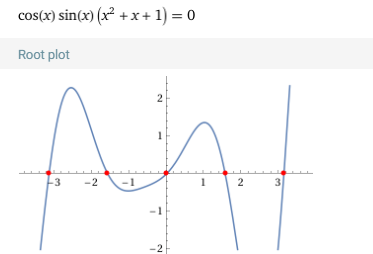

 # Знаходження коренів рівняння за допомогою бібліотеки SymPy

In [ ]:
import sympy as sym

x = sym.Symbol('x')

y = sym.cos(x)*sym.sin(x)*(x**2+x+1)

s = sym.solve(y, x)

print(s)

[0, pi/2, pi, 3*pi/2, -1/2 - sqrt(3)*I/2, -1/2 + sqrt(3)*I/2]


In [ ]:
import sympy as sym

x, a, b, c = sym.symbols('x, a, b, c')

y = a * x**2 + b * x + c

s = sym.solve(y, x)

print(s)

[(-b - sqrt(-4*a*c + b**2))/(2*a), (-b + sqrt(-4*a*c + b**2))/(2*a)]


In [ ]:
!pip install numdifftools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.5 MB/s eta 0:00:00


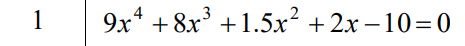

In [ ]:
#Лабораторна робота 2
#Відокремлення коренів
import numpy as np
import numdifftools as nd

def f(x):
    return 9*x**4 + 8*x**3 + 1.5*x**2 + 2*x - 10


def find_segments(): #відокремлюємо корені
    search_range = np.arange(-5, 5, 1)

    a = None
    previous_x = None
    current_x  = None
    segments = []

    for x in search_range:
        x = round(x, 4)
        current_x = f(x)
        if previous_x != None and previous_x * current_x < 0:
            segments.append((a, x))
        a = x
        previous_x = current_x
    return segments

segments = find_segments()
for a, b in segments:
    print(f'Found segment:  [{a}, {b}]')


Found segment:  [-2, -1]
Found segment:  [0, 1]


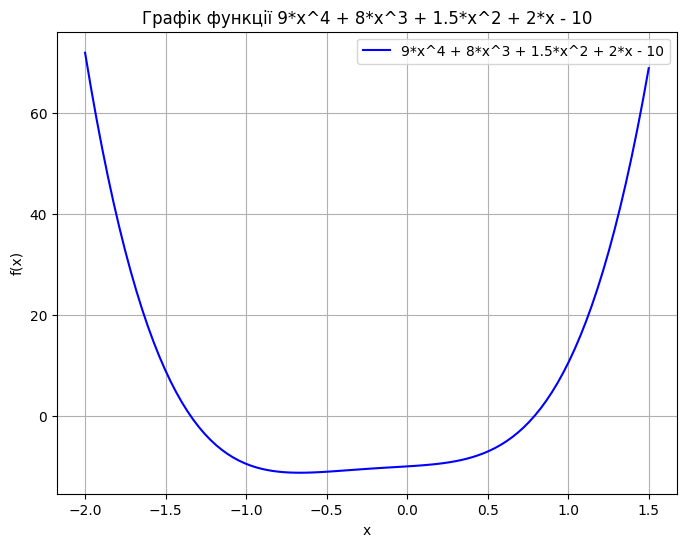

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Визначення функції
def f(x):
    return 9*x**4 + 8*x**3 + 1.5*x**2 + 2*x - 10

# Генерація значень x
x = np.linspace(-2, 1.5, 100)

# Генерація значень y
y = f(x)

# Побудова графіка
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='9*x^4 + 8*x^3 + 1.5*x^2 + 2*x - 10', color='blue')
plt.title('Графік функції 9*x^4 + 8*x^3 + 1.5*x^2 + 2*x - 10')
plt.xlabel('x')
plt.ylabel('f(x)')

# Додавання осей з стрілками
#plt.axhline(0, color='black', linewidth=0.5)
#plt.axvline(0, color='black', linewidth=0.5)

#plt.text(2.05, -4, 'x', ha='center', va='center')
#plt.text(-0.3, 190, 'y', ha='center', va='center')

plt.grid(True)
plt.legend()
plt.show()


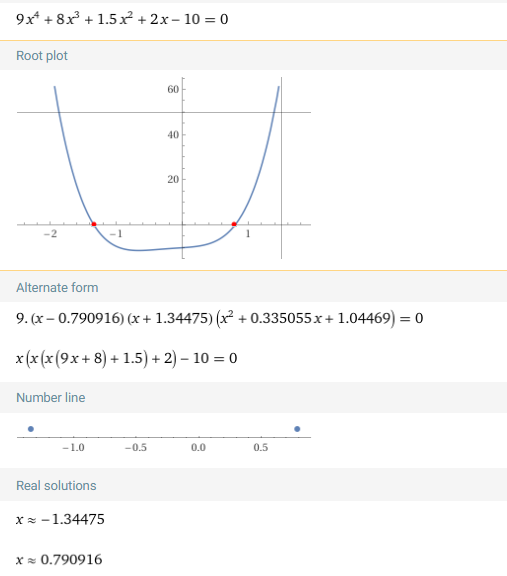

In [ ]:
#Лабораторна робота. Метод половинного ділення, хорд

def rec(a, b, eps):  # метод половинного ділення
    while (np.abs(a - b) > eps):
        if f(a) * f((a + b) / 2) < 0:
            b = (a + b) / 2
        else:
            a = (a + b) / 2
        x = (a + b) / 2

    print('x= ', round(x, 5), '  -   Half division method')


In [ ]:
def hord(a, b, eps):  # метод хорд
    derivative_f = nd.Derivative(f, n=2)
    if f(a) * derivative_f(a) > 0:
        x0 = a
        xi = b
    else:
        x0 = b
        xi = a
    xi_1 = xi - (xi - x0) * f(xi) / (f(xi) - f(x0))
    while (np.abs(xi_1 - xi) > eps):
        xi = xi_1
        xi_1 = xi - (xi - x0) * f(xi) / (f(xi) - f(x0))
    print('x= ', round(xi_1, 5), '  -   Chord method')


In [ ]:
if __name__ == "__main__":
    a1, b1 = -2, -1
    a2, b2 = 0, 1
    eps = 0.001
    print("Розв'язки на відрізку [-2,-1]")
    rec(a1, b1, eps)
    hord(a1, b1, eps)
    print("\n Розв'язки на відрізку [0,1]")
    rec(a2, b2, eps)
    hord(a2, b2, eps)

Розв'язки на відрізку [-2,-1]
x=  -1.34521   -   Half division method
x=  -1.34351   -   Chord method

 Розв'язки на відрізку [0,1]
x=  0.79053   -   Half division method
x=  0.7908   -   Chord method


In [ ]:
import sympy as sym

x, a, b, c = sym.symbols('x, a, b, c')
f = 9*x**4 + 8*x**3 + 1.5*x**2 + 2*x - 10
s = sym.solve(f, x)
print(s)

[-1.34474950432843, 0.790916098101000, -0.16752774133073 - 1.00827587207094*I, -0.16752774133073 + 1.00827587207094*I]


In [ ]:
#Лабораторна робота 3. Метод Ньютона (дотичних). Комбінований метод

def newton(a, b, eps, f, max_iter=100):
    df1 = nd.Derivative(f, n=1)
    df2 = nd.Derivative(f, n=2)

    xi = b if f(b) * df2(b) > 0 else a
    d = df1(xi)
    if d == 0:
        raise ZeroDivisionError("Похідна дорівнює нулю — зупинка.")

    xi_1 = xi - f(xi) / d
    it = 0
    while np.abs(xi_1 - xi) > eps and it < max_iter:
        xi = xi_1
        d = df1(xi)
        if d == 0:
            raise ZeroDivisionError("Похідна дорівнює нулю — зупинка.")
        xi_1 = xi - f(xi) / d
        it += 1

    print("Метод Ньютона, x =", round(float(xi_1), 4))

In [ ]:
def komb(a, b, eps, f, max_iter=200):
    df1 = nd.Derivative(f, n=1)
    df2 = nd.Derivative(f, n=2)

    # кінець для Ньютона обираємо так, щоб f(x)*f''(x) > 0
    if f(a) * df2(a) > 0:
        ai, bi = a, b
    else:
        ai, bi = b, a

    it = 0
    while np.abs(ai - bi) > eps and it < max_iter:
        denom = f(bi) - f(ai)
        if denom == 0:
            raise ZeroDivisionError("f(b) - f(a) = 0 у формулі хорди — зупинка.")

        ai_1 = ai - f(ai) * (bi - ai) / denom

        d = df1(bi)
        if d == 0:
            raise ZeroDivisionError("Похідна дорівнює нулю в методі Ньютона — зупинка.")
        bi_1 = bi - f(bi) / d

        ai, bi = ai_1, bi_1
        it += 1

    x = (ai + bi) / 2
    print("Комбінований метод, x =", round(float(x), 4))


In [ ]:
if __name__ == "__main__":
    a1, b1 = -2, -1
    a2, b2 = 0, 1
    eps = 0.001

    print("Розв'язання на відрізку [-2, -1]")
    newton(a1, b1, eps, f)
    komb(a1, b1, eps, f)
    print("\n Розв'язання на відрізку [0, 1]")
    newton(a2, b2, eps, f)
    komb(a2, b2, eps, f)

Розв'язання на відрізку [-2, -1]
Метод Ньютона, x = -1.3447
Комбінований метод, x = -1.3447

 Розв'язання на відрізку [0, 1]
Метод Ньютона, x = 0.7909
Комбінований метод, x = 0.7909


Завдання 3. Лабораторна робота 3

Тема: Відокремлення дійсних коренів рівнянь та їх уточнення методом простої ітерації.

In [ ]:
!pip install numdifftools

In [ ]:
import numdifftools as nd

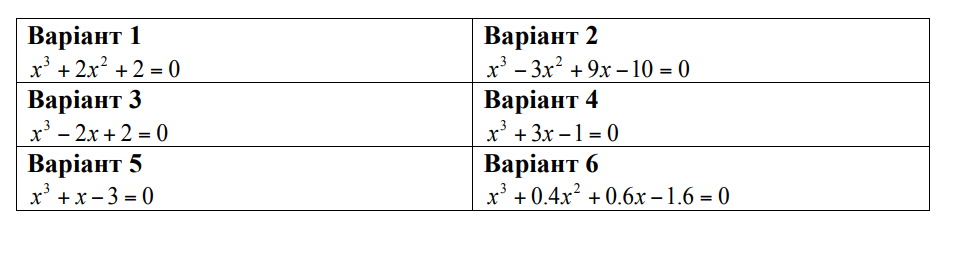

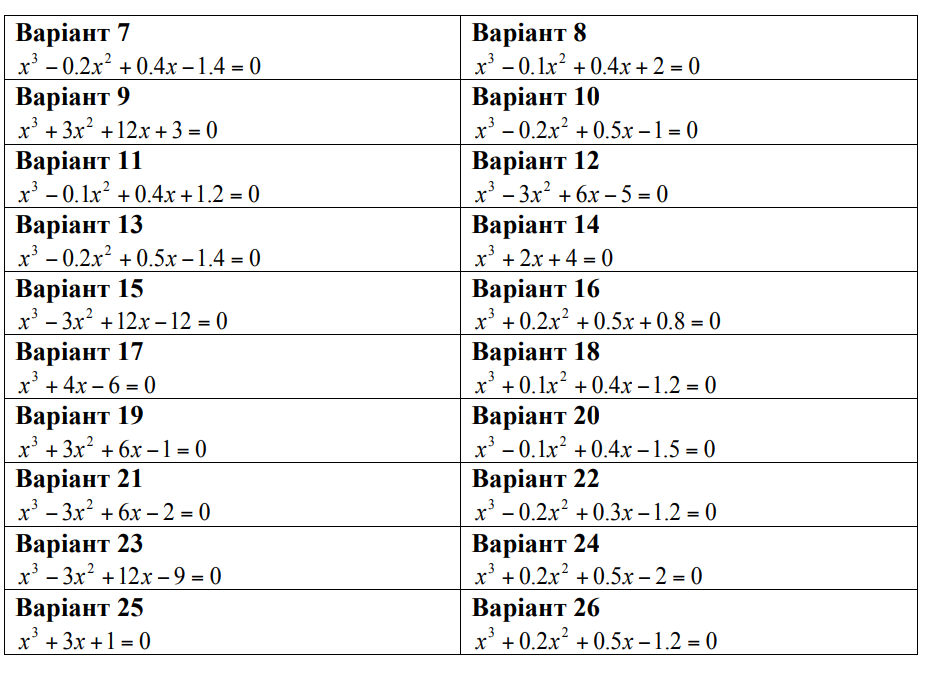

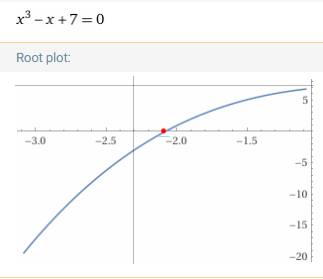

Визначаємо, що корінь належить відрізку [-3,-1]

In [ ]:
def f(x: float):
    return x**3 - x + 7

def fprime(x: float):
    return nd.Derivative(f, n=1)

def phi(x: float):
    # c = -0.1 (забезпечує |phi'(x)|<1 на [-3,-1])
    c = -0.1
    return x + c * f(x)

def iterate_fixed_point(x0: float, iters: int = 5):
    xs = [x0]
    x = x0
    for _ in range(iters):
        x = phi(x)
        xs.append(x)
    return xs

def error_bound(x_last: float) -> float:
    # μ = min_{x∈[-3,-1]} |f'(x)| = 2
    mu = 2.0
    return abs(f(x_last)) / mu



In [ ]:
def main():
    x0 = -1.0 # нульове наближення має належати відрізку [-3, -1]

    iters = 5
    xs = iterate_fixed_point(x0, iters)

    print("Fixed-point iteration for f(x) = x^3 - x + 7 with phi(x) = x - 0.1*f(x)")
    print(f"Interval: [-3, -1], start x0 = {x0}")

    for i, xi in enumerate(xs):
        if i == 0:
            print(f"x_{i} = {xi:.10f}")
        else:
            print(f"x_{i} = phi(x_{i-1}) = {xi:.10f}")
    bound = error_bound(xs[-1])
    print("\nError bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ")
    print(f"f(x5) = {f(xs[-1]):.10f},  μ = 2  ⇒  |ξ - x5| ≤ {bound:.10f}")
    return xs[-1], bound

if __name__ == "__main__":
    root_approx, bound = main()

Fixed-point iteration for f(x) = x^3 - x + 7 with phi(x) = x - 0.1*f(x)
Interval: [-3, -1], start x0 = -1.0
x_0 = -1.0000000000
x_1 = phi(x_0) = -1.7000000000
x_2 = phi(x_1) = -2.0787000000
x_3 = phi(x_2) = -2.0883650417
x_4 = phi(x_3) = -2.0864094687
x_5 = phi(x_4) = -2.0868145769

Error bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ
f(x5) = -0.0008352720,  μ = 2  ⇒  |ξ - x5| ≤ 0.0004176360


Спрощений варіант коду


In [ ]:
# Рівняння: f(x) = x^3 - x + 7 = 0
# Ітераційна функція: φ(x) = x - 0.1 * f(x)  (c = -0.1)
# Початкове наближення: x0 = -1
# Кількість ітерацій: 5
# Оцінка похибки: |ξ - x5| ≤ |f(x5)| / μ, де μ = min_{[-3,-1]} |f'(x)| = 2

def f(x):
    return x**3 - x + 7

def phi(x):
    return x - 0.1 * f(x)   # c = -0.1

def fixed_point(x0=-1.0, iters=5):
    xs = [x0]
    for _ in range(iters):
        xs.append(phi(xs[-1]))
    return xs

# Запуск і вивід результатів
xs = fixed_point(-1.0, 5)

for i, xi in enumerate(xs):
    print(f"x_{i} = {xi:.10f}")

# Похибка методу простої ітерації після 5-ї ітерації
mu = 2.0                      # μ = min_{[-3,-1]} |3x^2 - 1| = 2
err_bound = abs(f(xs[-1]))/mu
print(f"\nОцінка похибки: |ξ - x5| ≤ {err_bound:.10f}")

x_0 = -1.0000000000
x_1 = -1.7000000000
x_2 = -2.0787000000
x_3 = -2.0883650417
x_4 = -2.0864094687
x_5 = -2.0868145769

Оцінка похибки: |ξ - x5| ≤ 0.0004176360


Перевірка

In [ ]:
import sympy as sym

a, b = -3, -1

x, a, b = sym.symbols('x, a, b')
f = x**3 - x + 7

s = sym.solve(f, x)
print(s)

[-1/((-1/2 - sqrt(3)*I/2)*(3*sqrt(3957)/2 + 189/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(3*sqrt(3957)/2 + 189/2)**(1/3)/3, -(-1/2 + sqrt(3)*I/2)*(3*sqrt(3957)/2 + 189/2)**(1/3)/3 - 1/((-1/2 + sqrt(3)*I/2)*(3*sqrt(3957)/2 + 189/2)**(1/3)), -(3*sqrt(3957)/2 + 189/2)**(1/3)/3 - 1/(3*sqrt(3957)/2 + 189/2)**(1/3)]
